# Tutorial: automatic quality control of scRNA-seq with `validrops`

[`validrops`](https://github.com/tuhulab/validrops-py) is a Python/scanpy port of the R
package [valiDrops](https://doi.org/10.1093/nargab/lqad101) (Kavaliauskaite & Madsen, *NAR
Genomics and Bioinformatics*, 2023). It performs automated quality control of droplet-based
single-cell and single-nucleus RNA-seq data in four stages:

| Stage | Function | What it does |
|---|---|---|
| 1 | `validrops.pp.rank_barcodes` | Rank barcodes by UMI/gene count and detect the knee separating cells from ambient RNA |
| 2 | `validrops.tl.quality_metrics` + `validrops.pp.quality_filter` | Per-barcode mito/ribo/coding fractions, log UMI/feature counts, and filtering on those metrics |
| 3 | `validrops.tl.expression_metrics` + `validrops.pp.expression_filter` | HVG selection, low-dimensional embedding, SNN + Louvain clustering, and per-cluster marker stats; drop clusters without coherent marker expression |
| 4 *(optional)* | `validrops.pp.label_dead` | Heuristic dead-cell score plus a consensus ridge-training loop |

The package is distributed on PyPI as **`validrops-py`** and imported as **`validrops`**.

This notebook walks through the whole pipeline on a real 10x Genomics PBMC 4K raw count
matrix — the same dataset used for validation against the R implementation. You can follow
along with any 10x raw feature-barcode matrix (empty droplets included — that is exactly the
input the tool is designed for).

## 1. Setup

Run this notebook from the repository root (`git clone https://github.com/tuhulab/validrops-py`).
We recommend [uv](https://github.com/astral-sh/uv): `uv sync --group test`.

The pipeline logs progress with the `logging` module. By default it logs to stderr; we route
it to stdout here so the stage-by-stage narration shows up in the rendered notebook.

In [1]:
import logging
import sys

import scanpy as sc
import validrops

# The pipeline logs progress with `logging`; route it to stdout so the stage-
# by-stage narration shows up in the rendered notebook.
logging.basicConfig(stream=sys.stdout, level=logging.INFO, format="%(levelname)s %(name)s: %(message)s")

print("validrops", validrops.__version__)

validrops 0.0.1


## 2. Load a droplet-based 10x matrix

`validrops` expects the **raw** CellRanger output — every barcode, including the vast
majority that only captured ambient RNA. Those empty droplets are what stage 1 removes.

The reference data used for the R↔Python validation lives at `tests/data/pbmc4k/raw.h5`
(10x Genomics *PBMC 4k*, v3 chemistry, raw feature-barcode matrix; gitignored because it is
17 MB). Point `VALIDROPS_RAW_H5` at your own 10x `.h5` (or raw MTX) matrix to work on
different data — any species in the embedded annotation table (human, mouse, rat,
zebrafish, worm, fly) is auto-detected from the gene IDs.

In [2]:
import os
from pathlib import Path

raw_h5 = os.environ.get("VALIDROPS_RAW_H5")
if not raw_h5:
    for candidate in (
        Path("tests/data/pbmc4k/raw.h5"),
        Path("../tests/data/pbmc4k/raw.h5"),
    ):
        if candidate.exists():
            raw_h5 = str(candidate)
            break

if not raw_h5 or not Path(raw_h5).exists():
    raise FileNotFoundError(
        "Raw 10x matrix not found. Download the PBMC 4K raw feature-barcode matrix from 10x "
        "Genomics (e.g. pbmc_4k_raw_feature_bc_matrix.h5) and save it as "
        "tests/data/pbmc4k/raw.h5, or set $VALIDROPS_RAW_H5 to your own 10x matrix."
    )

adata = sc.read_10x_h5(raw_h5)
adata.var_names_make_unique()  # some gene symbols collide in the raw table
print(f"loaded {adata.n_obs:,} barcodes x {adata.n_vars:,} genes, dtype={adata.X.dtype}")

loaded 737,280 barcodes x 33,694 genes, dtype=float32


/Users/tuhu/Projects/validrops/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


## 3. Run the full pipeline

{py:func}`validrops.validrops` runs all stages in one call. It annotates
`adata` **in place** — nothing is ever removed from the object; the quality verdicts land in
`adata.obs` and the thresholds/gene sets/parameters land in `adata.uns["validrops"]`.

- `label_dead=False` by default: stage 4 is stochastic and much slower than the rest.
- `verbose=True` logs each step.
- Every stochastic step is seeded via `random_state=0`, so runs are reproducible.

In [3]:
%time validrops.validrops(adata)

INFO validrops._pipeline: Step 1: Filtering on the barcode-rank plot.


INFO validrops.pp.rank_barcodes: Step 1: 5189 barcodes passed the rank threshold (111.0 counts)


INFO validrops._pipeline: Step 2: Collecting quality metrics.


INFO validrops._pipeline: Step 3: Filtering on quality metrics.


INFO validrops.pp.quality_filter: Step 3: 4790 barcodes passed quality filtering


...

INFO validrops.tl.expression_metrics: Step 4: 112 clusters with marker statistics


INFO validrops._pipeline: Step 5: Filtering on expression-based metrics.


INFO validrops.pp.expression_filter: Step 5: 89 of 112 clusters passed, keeping 3766 barcodes


INFO validrops._pipeline: 	3766 barcodes passed quality control.


CPU times: user 56.8 s, sys: 2.63 s, total: 59.5 s
Wall time: 56.6 s


## 4. What happened?

The verdicts are per-barcode booleans in `adata.obs`. The first rows are empty-droplet barcodes, so all flags are `False` for them — that is stage 1 doing its job.

```{note}
The pipeline only annotates `adata`; the QC flags read exactly like the R implementation's output columns.
```

In [4]:
qc_columns = [
    "rank_pass",
    "pass_mito",
    "pass_distance",
    "pass_coding",
    "pass_contrast",
    "qc_pass",
]
adata.obs[qc_columns].head(10)

,rank_pass,pass_mito,pass_distance,pass_coding,pass_contrast,qc_pass
AAACCTGAGAAACCAT-1,False,False,False,False,False,False
AAACCTGAGAAACCGC-1,False,False,False,False,False,False
AAACCTGAGAAACCTA-1,False,False,False,False,False,False
AAACCTGAGAAACGAG-1,False,False,False,False,False,False
AAACCTGAGAAACGCC-1,False,False,False,False,False,False
AAACCTGAGAAAGTGG-1,False,False,False,False,False,False
AAACCTGAGAACAACT-1,False,False,False,False,False,False
AAACCTGAGAACAATC-1,False,False,False,False,False,False
AAACCTGAGAACTCGG-1,False,False,False,False,False,False
AAACCTGAGAACTGTA-1,False,False,False,False,False,False


In [5]:
adata.obs.loc[adata.obs["qc_pass"], qc_columns].head(6)

,rank_pass,pass_mito,pass_distance,pass_coding,pass_contrast,qc_pass
AAACCTGAGAAGGCCT-1,True,True,True,True,True,True
AAACCTGAGCGCCTCA-1,True,True,True,True,True,True
AAACCTGAGGCATGGT-1,True,True,True,True,True,True
AAACCTGCAAGGTTCT-1,True,True,True,True,True,True
AAACCTGCAGGATTGG-1,True,True,True,True,True,True
AAACCTGCAGGCGATA-1,True,True,True,True,True,True


In [6]:
import pandas as pd

passes = adata.obs[qc_columns].sum()
summary = pd.DataFrame(
    {
        "stage": [
            "1 · barcode ranking",
            "2 · quality metrics",
            "3 · expression-based",
            "final · qc_pass",
        ],
        "barcodes passing": [
            passes["rank_pass"],
            (
                adata.obs["pass_mito"]
                & adata.obs["pass_distance"]
                & adata.obs["pass_coding"]
                & adata.obs["pass_contrast"]
            ).sum(),
            passes["qc_pass"],
            passes["qc_pass"],
        ],
        "criterion": [
            "above the UMI knee",
            "mito cap, UMI↔feature residual band, coding fraction, contrast",
            "cluster-level marker coherence (each passing cell belongs to a kept cluster)",
            "passed stages 1–3",
        ],
    }
)
summary

,stage,barcodes passing,criterion
0,1 · barcode ranking,5189,above the UMI knee
1,2 · quality metrics,4790,"mito cap, UMI↔feature residual band, coding fr..."
2,3 · expression-based,3766,cluster-level marker coherence (each passing c...
3,final · qc_pass,3766,passed stages 1–3


In [7]:
uns = adata.uns["validrops"]
print("rank threshold        :", round(float(uns["rank_threshold"]), 2), "counts")
print("mitochondrial cap     :", uns["mitochondrial_threshold"], f"({uns['mito_threshold_method']})")
print("species               :", uns["species"], "| annotation column:", uns["annotation_column"])
print(
    "genes mapped          :", uns["n_mapped"], "| mito/ribo/coding:", {k: len(v) for k, v in uns["gene_sets"].items()}
)
print("stored parameters     :", uns["params"])

rank threshold        : 111.0 counts
mitochondrial cap     : 0.07936389245694836 (gmm_uik)
species               : human | annotation column: Symbol
genes mapped          : 21169 | mito/ribo/coding: {'mitochondrial': 13, 'ribosomal': 102, 'protein_coding': 18278}
stored parameters     : {'rank_barcodes': True, 'stage_three': True, 'label_dead': False, 'mitochondrial_clusters': 3, 'ribosomal_clusters': 3, 'random_state': 0}


## 5. Diagnostic plots

`validrops.pl` ships the QC figures from the valiDrops paper. All of them read the results
written by the pipeline, so they work straight after the run.

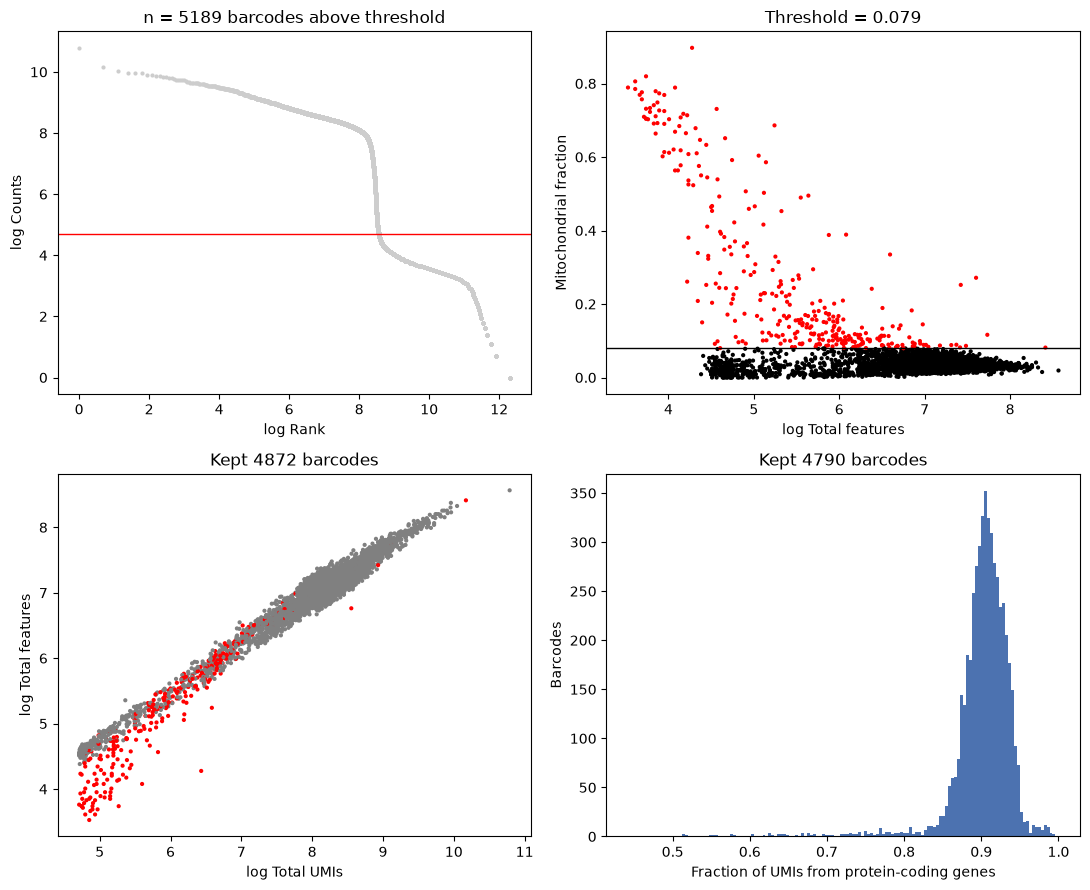

In [8]:
%matplotlib inline
import matplotlib.pyplot as plt
import validrops.pl as pl

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
pl.barcode_rank(adata, ax=axes[0, 0])
pl.mito_threshold(adata, ax=axes[0, 1])
pl.umi_vs_features(adata, ax=axes[1, 0])
pl.coding_fraction(adata, ax=axes[1, 1])
fig.tight_layout()

## 6. Step-by-step: the modular API

Each stage is a public function on its own. Running them in sequence with the same seed
produces the identical verdict as the one-shot call — `validrops.validrops` is just a
convenience wrapper around this composition. This is handy for instrumenting a single stage
or running stage 2 only (`stage_three=False`).

In [9]:
import validrops.pp as pp
import validrops.tl as tl

manual = adata.copy()  # fresh scratch objects; nothing shared with the one-shot run

pp.rank_barcodes(manual, random_state=0)
print("stage 1 ->", int(manual.obs["rank_pass"].sum()), "barcodes")

tl.quality_metrics(manual)
pp.quality_filter(manual, random_state=0)
n_stage2 = int(
    (
        manual.obs["pass_mito"] & manual.obs["pass_distance"] & manual.obs["pass_coding"] & manual.obs["pass_contrast"]
    ).sum()
)
print("stage 2 ->", n_stage2, "barcodes")

tl.expression_metrics(manual, random_state=0)
n_clusters = len(manual.uns["validrops"]["cluster_stats"])
print("stage 3a ->", n_clusters, "clusters, marker stats computed")

pp.expression_filter(manual)
print("stage 3b ->", int(manual.obs["qc_pass"].sum()), "barcodes")

INFO validrops.pp.rank_barcodes: Step 1: 5189 barcodes passed the rank threshold (111.0 counts)


stage 1 -> 5189 barcodes


INFO validrops.pp.quality_filter: Step 3: 4790 barcodes passed quality filtering


stage 2 -> 4790 barcodes


INFO validrops.tl.expression_metrics: Step 4: 112 clusters with marker statistics


stage 3a -> 112 clusters, marker stats computed
INFO validrops.pp.expression_filter: Step 5: 89 of 112 clusters passed, keeping 3766 barcodes


stage 3b -> 3766 barcodes


In [10]:
agree = int((manual.obs["qc_pass"] == adata.obs["qc_pass"]).sum())
print(f"step-by-step and one-shot agree on {agree:,} / {adata.n_obs:,} barcodes")

step-by-step and one-shot agree on 737,280 / 737,280 barcodes


## 7. Extract the clean dataset

Because the pipeline only annotates, the clean object is a plain subset — and it still holds
**raw counts**. `validrops` is a QC tool, not a normalisation one: run `sc.pp.normalize_total`
etc. *after* filtering.

In [11]:
clean = adata[adata.obs["qc_pass"]].copy()
print("clean dataset:", clean.shape)
clean.obs[["log_umis", "log_features", "mitochondrial_fraction", "ribosomal_fraction"]].describe().T

clean dataset: (3766, 33694)


,count,mean,std,min,25%,50%,75%,max
log_umis,3766.0,8.294629,0.505040,4.727388,8.079153,8.304495,8.532476,10.045811
log_features,3766.0,7.144013,0.368962,4.477337,6.989335,7.142037,7.309045,8.327001
mitochondrial_fraction,3766.0,0.029803,0.011409,0.000000,0.021892,0.027545,0.035509,0.079336
ribosomal_fraction,3766.0,0.373047,0.097521,0.020084,0.299066,0.392470,0.451620,0.558579


## 8. Options and the dead-cell stage

The main switches mirror the R function: `rank_barcodes`, `stage_three`, `label_dead`,
`mitochondrial_clusters`, `ribosomal_clusters`, and `random_state`. Extra keyword arguments
are forwarded to the individual stage functions by name.

Stage 4 (`label_dead=True`) adds `obs["dead_score"]` and `obs["label"]` (dead/live) via a
consensus of ridge classifiers trained on heuristically-labelled extreme cells. It is off by
default because it is stochastic and slow (~10 training rounds with a 5-fold search). It only
meaningful on datasets with a real dead-cell fraction — run the rest of the pipeline first
and inspect the diagnostic plots before enabling it.

In [12]:
import inspect

print(inspect.signature(validrops.validrops))
print()
print("plotting API:", validrops.pl.__all__)

(adata: anndata._core.anndata.AnnData, *, rank_barcodes: bool = True, stage_three: bool = True, label_dead: bool = False, mitochondrial_clusters: float | None = 3, ribosomal_clusters: float | None = 3, random_state: int = 0, verbose: bool = True, **kwargs) -> None

plotting API: ['barcode_rank', 'coding_fraction', 'dead_score', 'mito_threshold', 'umi_vs_features']


## Citation

If `validrops` contributes to a publication, please cite the original R package:

> Kavaliauskaite, G. & Madsen, J. G. S. (2023). Automatic quality control of single-cell and
> single-nucleus RNA-seq using valiDrops. *NAR Genomics and Bioinformatics*, 5(4), lqad101.
> https://doi.org/10.1093/nargab/lqad101

See `CITATION.cff` in the repository for the machine-readable record.